In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("imdb_top_1000.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [5]:
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [6]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [7]:
df.shape

(1000, 16)

In [8]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [9]:
df.isna().sum()

,0
Poster_Link,0
Series_Title,0
Released_Year,0
Certificate,101
Runtime,0
Genre,0
IMDB_Rating,0
Overview,0
Meta_score,157
Director,0


In [10]:
(df.isnull().sum() / len(df)) * 100

,0
Poster_Link,0.0
Series_Title,0.0
Released_Year,0.0
Certificate,10.1
Runtime,0.0
Genre,0.0
IMDB_Rating,0.0
Overview,0.0
Meta_score,15.7
Director,0.0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df['Genre'].unique()

array(['Drama', 'Crime, Drama', 'Action, Crime, Drama',
       'Action, Adventure, Drama', 'Biography, Drama, History',
       'Action, Adventure, Sci-Fi', 'Drama, Romance', 'Western',
       'Action, Sci-Fi', 'Biography, Crime, Drama',
       'Action, Adventure, Fantasy', 'Comedy, Drama, Thriller',
       'Adventure, Drama, Sci-Fi', 'Animation, Adventure, Family',
       'Drama, War', 'Crime, Drama, Fantasy', 'Comedy, Drama, Romance',
       'Crime, Drama, Mystery', 'Crime, Drama, Thriller',
       'Action, Drama, Mystery', 'Drama, Family, Fantasy', 'Drama, Music',
       'Biography, Comedy, Drama', 'Drama, Mystery, Sci-Fi',
       'Biography, Drama, Music', 'Crime, Mystery, Thriller',
       'Animation, Adventure, Drama', 'Animation, Drama, War',
       'Adventure, Comedy, Sci-Fi', 'Horror, Mystery, Thriller',
       'Drama, Romance, War', 'Comedy, Drama, Family',
       'Animation, Drama, Fantasy', 'Action, Biography, Drama',
       'Animation, Action, Adventure', 'Drama, Western',


In [14]:
df['Certificate'].value_counts().sort_values(ascending=False)

,count
Certificate,
U,234
A,197
UA,175
R,146
PG-13,43
PG,37
Passed,34
G,12
Approved,11


In [15]:
df.drop(columns='Poster_Link',inplace=True)

In [16]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [17]:
df["Gross"].head()

,Gross
0,"28,341,469"
1,"134,966,411"
2,"534,858,444"
3,"57,300,000"
4,"4,360,000"


In [18]:
df['Gross'] = df['Gross'].str.replace(",","")

In [19]:
df['Gross'].head()

,Gross
0,28341469
1,134966411
2,534858444
3,57300000
4,4360000


In [20]:
df['Gross'] = pd.to_numeric(df['Gross'],errors='coerce')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   object 
 4   Genre          1000 non-null   object 
 5   IMDB_Rating    1000 non-null   float64
 6   Overview       1000 non-null   object 
 7   Meta_score     843 non-null    float64
 8   Director       1000 non-null   object 
 9   Star1          1000 non-null   object 
 10  Star2          1000 non-null   object 
 11  Star3          1000 non-null   object 
 12  Star4          1000 non-null   object 
 13  No_of_Votes    1000 non-null   int64  
 14  Gross          831 non-null    float64
dtypes: float64(3), int64(1), object(11)
memory usage: 117.3+ KB


In [22]:
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

In [23]:
df.dtypes

,0
Series_Title,object
Released_Year,float64
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object
Star1,object


In [24]:
movies_90 = df[(df['Released_Year']>=1990) & (df['Released_Year']<=2000)]

In [25]:
movies_90.shape

(169, 15)

In [26]:
director_gross = movies_90.groupby('Director')['Gross'].sum().sort_values(ascending=False)

In [27]:
director_gross.head()

,Gross
Director,
James Cameron,864168729.0
Steven Spielberg,715893609.0
Robert Zemeckis,563884324.0
John Lasseter,437648412.0
Roger Allers,422783777.0


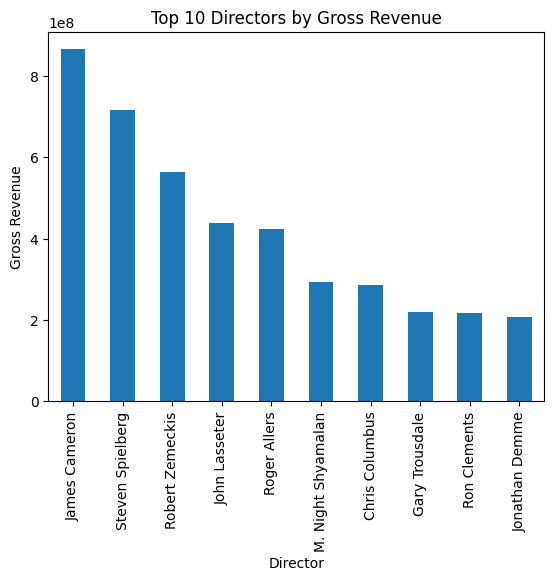

In [28]:
director_gross.head(10).plot(kind='bar')
plt.title('Top 10 Directors by Gross Revenue')
plt.xlabel('Director')
plt.ylabel('Gross Revenue')
plt.show()

In [29]:
df.columns

Index(['Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre',
       'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2',
       'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

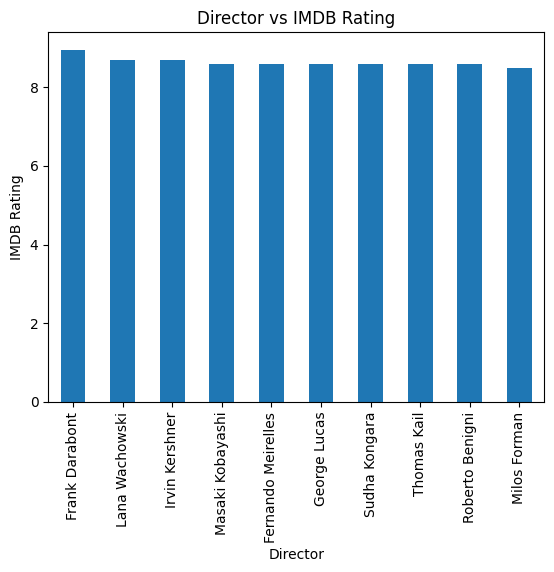

In [32]:
df.groupby("Director")["IMDB_Rating"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Director vs IMDB Rating")
plt.xlabel("Director")
plt.ylabel("IMDB Rating")
plt.show()

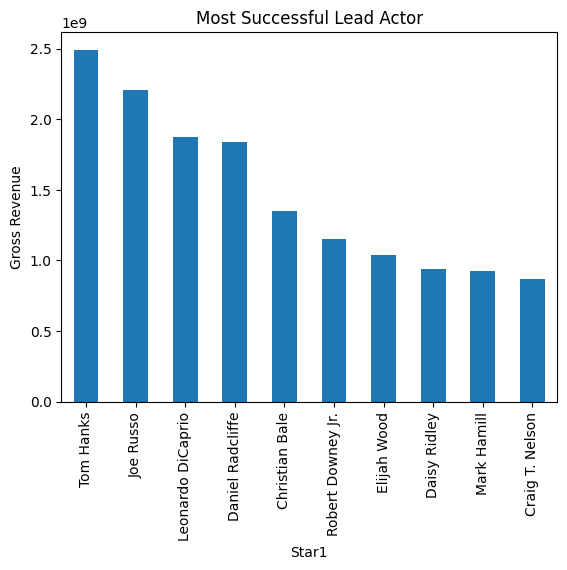

In [34]:
df.groupby("Star1")["Gross"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Most Successful Lead Actor")
plt.xlabel("Star1")
plt.ylabel("Gross Revenue")
plt.show()

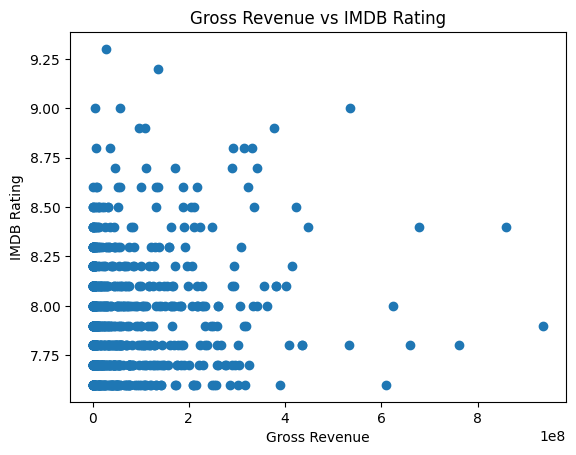

In [35]:
plt.scatter(df["Gross"],df["IMDB_Rating"])
plt.title("Gross Revenue vs IMDB Rating")
plt.xlabel("Gross Revenue")
plt.ylabel("IMDB Rating")
plt.show()

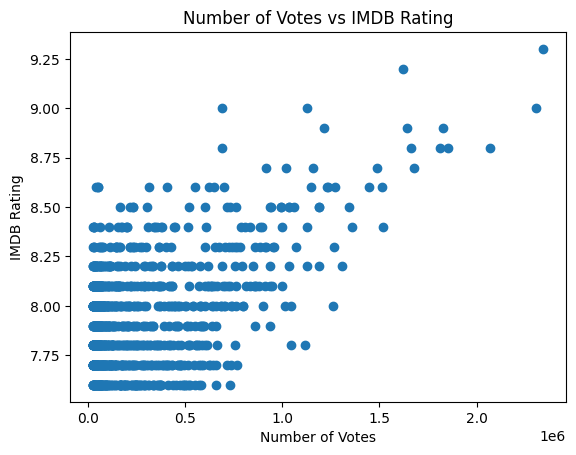

In [37]:
plt.scatter(df['No_of_Votes'],df['IMDB_Rating'])
plt.title('Number of Votes vs IMDB Rating')
plt.xlabel('Number of Votes')
plt.ylabel('IMDB Rating')
plt.show()

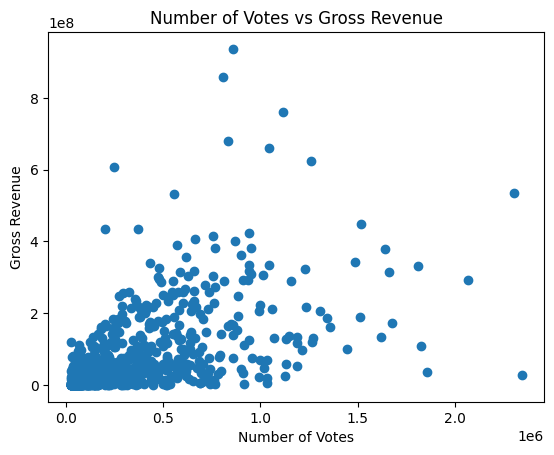

In [39]:
plt.scatter(df['No_of_Votes'],df['Gross'])
plt.title('Number of Votes vs Gross Revenue')
plt.xlabel('Number of Votes')
plt.ylabel('Gross Revenue')
plt.show()

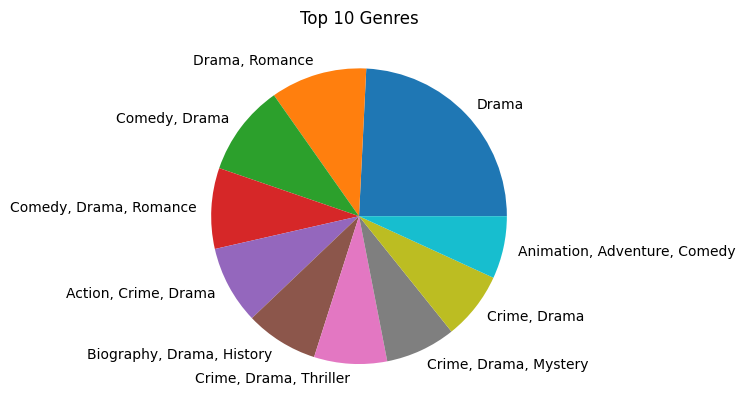

In [43]:
df['Genre'].value_counts().sort_values(ascending=False).head(10).plot(kind='pie')
plt.title('Top 10 Genres')
plt.ylabel('')
plt.show()

In [46]:
df["Runtime"] = df["Runtime"].str.replace(" min", "", regex=False).astype(int)

In [47]:
runtime_trend = (
    df.groupby("Released_Year")["Runtime"]
      .mean()
      .sort_index()
)

print(runtime_trend)

Released_Year
1920.0     76.000000
1921.0     68.000000
1922.0     94.000000
1924.0     45.000000
1925.0     85.000000
             ...    
2016.0    123.642857
2017.0    121.590909
2018.0    128.105263
2019.0    132.130435
2020.0    126.666667
Name: Runtime, Length: 99, dtype: float64


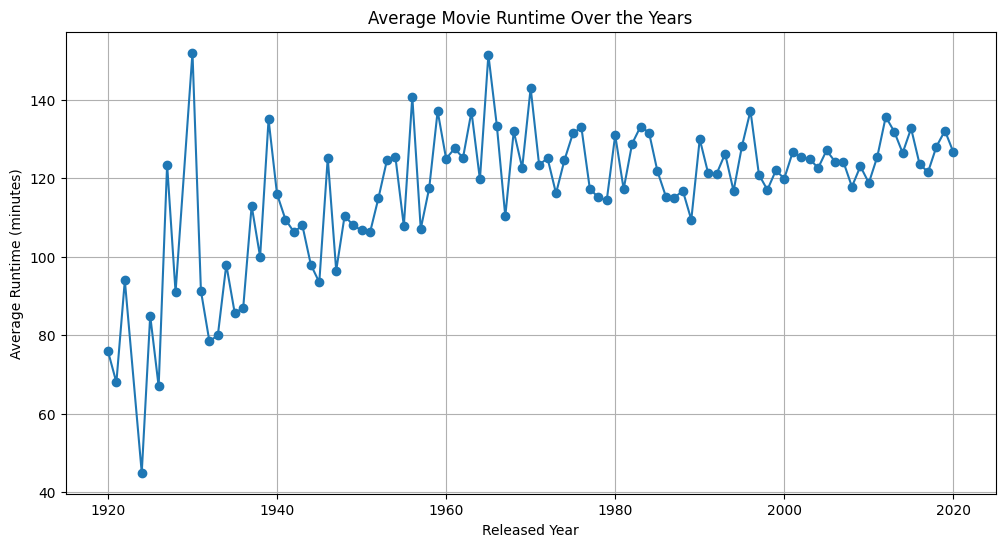

In [48]:
plt.figure(figsize=(12,6))
plt.plot(runtime_trend.index, runtime_trend.values, marker='o')

plt.title("Average Movie Runtime Over the Years")
plt.xlabel("Released Year")
plt.ylabel("Average Runtime (minutes)")
plt.grid(True)

plt.show()

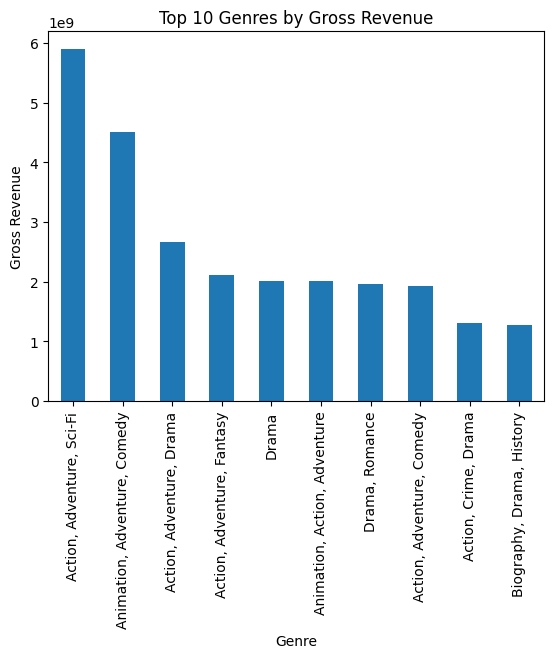

In [49]:
df.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

